# 🔬 VGG16 + VDE Feature Selection for Pneumonia Detection



In [ ]:
!pip install -q tensorflow scikit-learn seaborn matplotlib numpy

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Dense, Flatten, Dropout
from keras.models import Model, Sequential
from keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score, f1_score, precision_score, recall_score
import warnings
import pickle
import json
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print('✅ All packages imported successfully!')
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU Available: {len(tf.config.list_physical_devices("GPU"))} GPU(s)')

✅ All packages imported successfully!
TensorFlow version: 2.19.0
GPU Available: 1 GPU(s)


In [ ]:
IMAGE_SIZE = [224, 224]
BATCH_SIZE = 32
EPOCHS = 20

GLOBAL_DATA = {
    'vde_feature_mask': None,
    'vde_fitness_history': None,
    'vde_model': None,
    'vde_history': None,
    'vde_predictions': None,
    'vde_test_labels': None,
    'vde_metrics': {},
    'feature_extractor': None,
    'X_train_vde': None,
    'y_train': None,
    'training_set': None,
    'validation_set': None,
    'test_set': None,
    'num_classes': None,
    'class_names': None
}

SAVE_DIR = '/content/results'
os.makedirs(SAVE_DIR, exist_ok=True)

print('✅ Global variables initialized!')
print(f'Configuration: Image Size={IMAGE_SIZE}, Batch Size={BATCH_SIZE}, Epochs={EPOCHS}')

✅ Global variables initialized!
Configuration: Image Size=[224, 224], Batch Size=32, Epochs=20


In [ ]:
print('GPU Available: ', tf.config.list_physical_devices('GPU'))
if tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True)
    print('🚀 GPU memory growth enabled!')
else:
    print('⚠️ No GPU found. Training will use CPU.')

GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
🚀 GPU memory growth enabled!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

train_path = '/content/drive/MyDrive/chest_xray/train'
test_path = '/content/drive/MyDrive/chest_xray/test'
val_path = '/content/drive/MyDrive/chest_xray/val'

for path_name, path in [('Train', train_path), ('Test', test_path), ('Val', val_path)]:
    if os.path.exists(path):
        print(f'✅ {path_name}: {path}')
        for cls in os.listdir(path):
            cls_path = os.path.join(path, cls)
            if os.path.isdir(cls_path):
                count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
                print(f'   {cls}: {count} images')
    else:
        print(f'❌ {path_name} not found!')

Mounted at /content/drive
✅ Train: /content/drive/MyDrive/chest_xray/train
   PNEUMONIA: 3876 images
   NORMAL: 1341 images
✅ Test: /content/drive/MyDrive/chest_xray/test
   PNEUMONIA: 690 images
   NORMAL: 434 images
✅ Val: /content/drive/MyDrive/chest_xray/val
   PNEUMONIA: 8 images
   NORMAL: 8 images


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=10, width_shift_range=0.1, height_shift_range=0.1, shear_range=0.1, zoom_range=0.1, horizontal_flip=True, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(train_path, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='training')
validation_set = train_datagen.flow_from_directory(train_path, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='validation')
test_set = test_datagen.flow_from_directory(test_path, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

GLOBAL_DATA['training_set'] = training_set
GLOBAL_DATA['validation_set'] = validation_set
GLOBAL_DATA['test_set'] = test_set
GLOBAL_DATA['num_classes'] = len(training_set.class_indices)
GLOBAL_DATA['class_names'] = list(training_set.class_indices.keys())

print(f'📊 Classes: {GLOBAL_DATA["num_classes"]}, Names: {GLOBAL_DATA["class_names"]}')
print(f'Training: {training_set.samples}, Validation: {validation_set.samples}, Test: {test_set.samples}')

Found 4174 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 1124 images belonging to 2 classes.
📊 Classes: 2, Names: ['NORMAL', 'PNEUMONIA']
Training: 4174, Validation: 1043, Test: 1124


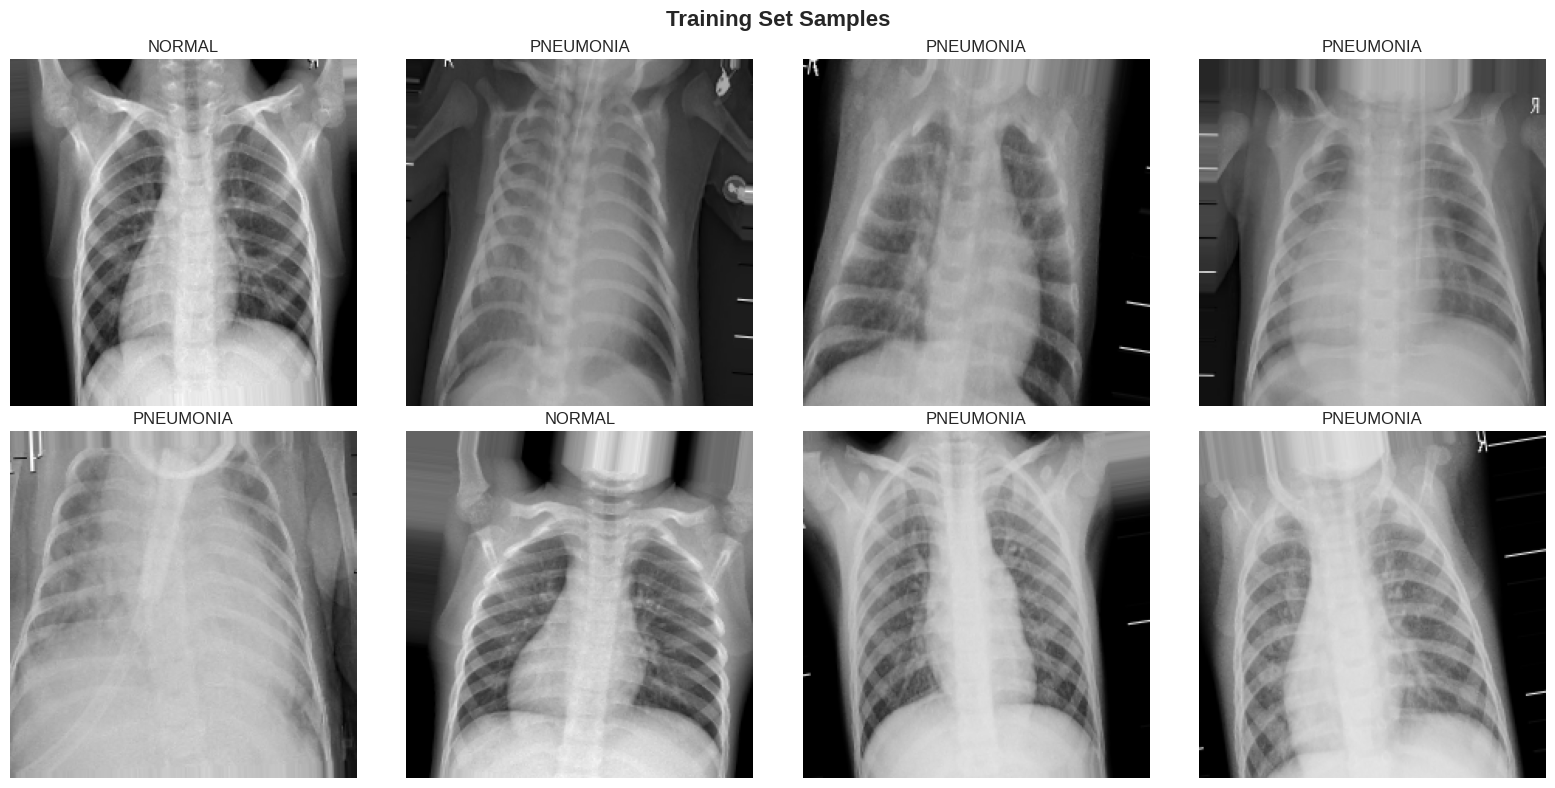

In [ ]:
def show_sample_images(generator, title='Sample Images'):
    class_names = list(generator.class_indices.keys())
    batch_x, batch_y = next(generator)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    for i in range(8):
        row, col = i // 4, i % 4
        axes[row, col].imshow(batch_x[i])
        axes[row, col].set_title(f"{class_names[np.argmax(batch_y[i])]}")
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/sample_images.png', dpi=300, bbox_inches='tight')
    plt.show()

show_sample_images(training_set, 'Training Set Samples')

In [ ]:
class VDEFeatureSelector:
    def __init__(self, population_size=10, max_generations=10, F=0.5, CR=0.7):
        self.population_size = population_size
        self.max_generations = max_generations
        self.F = F
        self.CR = CR

    def fitness_function(self, individual, X, y):
        selected_features = X[:, individual == 1]
        if selected_features.shape[1] == 0:
            return 0.0
        knn = KNeighborsClassifier(n_neighbors=3)
        try:
            scores = cross_val_score(knn, selected_features, y, cv=3, scoring='accuracy')
            return np.mean(scores)
        except:
            return 0.0

    def mutate(self, population, target_idx):
        candidates = [i for i in range(self.population_size) if i != target_idx]
        r1, r2, r3 = np.random.choice(candidates, 3, replace=False)
        mutant = population[r1] + self.F * (population[r2] - population[r3])
        mutant = np.clip(mutant, 0, 1)
        return (mutant > 0.5).astype(int)

    def crossover(self, target, mutant):
        D = len(target)
        cross_points = np.random.rand(D) < self.CR
        if not np.any(cross_points):
            cross_points[np.random.randint(0, D)] = True
        return np.where(cross_points, mutant, target)

    def select_features(self, X, y):
        D = X.shape[1]
        print(f"🧬 VDE: {self.population_size} individuals, {D} features")
        population = np.random.randint(0, 2, size=(self.population_size, D))
        for i in range(self.population_size):
            if np.sum(population[i]) == 0:
                population[i][np.random.randint(0, D)] = 1

        best_fitness_history = []
        print(f"🚀 Evolving for {self.max_generations} generations...")

        for generation in range(self.max_generations):
            fitness_values = [self.fitness_function(ind, X, y) for ind in population]
            best_fitness = max(fitness_values)
            best_fitness_history.append(best_fitness)
            print(f"Gen {generation+1}/{self.max_generations}: Best={best_fitness:.4f}, Avg={np.mean(fitness_values):.4f}")

            new_population = []
            for i in range(self.population_size):
                mutant = self.mutate(population, i)
                trial = self.crossover(population[i], mutant)
                trial_fitness = self.fitness_function(trial, X, y)
                if trial_fitness >= fitness_values[i]:
                    new_population.append(trial)
                else:
                    new_population.append(population[i])
            population = np.array(new_population)

        final_fitness = [self.fitness_function(ind, X, y) for ind in population]
        best_individual = population[np.argmax(final_fitness)]
        print(f"✅ Evolution complete! Selected {np.sum(best_individual)}/{D} features")
        return best_individual, best_fitness_history

print('✅ VDEFeatureSelector defined!')

✅ VDEFeatureSelector defined!


In [ ]:
def extract_features_and_apply_vde():
    print("🔧 Creating VGG16 feature extractor...")
    vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=IMAGE_SIZE + [3])
    feature_extractor = Model(inputs=vgg_base.input, outputs=vgg_base.output)
    GLOBAL_DATA['feature_extractor'] = feature_extractor

    print("🔄 Extracting training features...")
    train_features, train_labels = [], []
    for i, (batch_x, batch_y) in enumerate(GLOBAL_DATA['training_set']):
        if i >= len(GLOBAL_DATA['training_set']):
            break
        features = feature_extractor.predict(batch_x, verbose=0)
        train_features.append(features)
        train_labels.append(batch_y)
        if (i + 1) % 10 == 0:
            print(f"   {i+1}/{len(GLOBAL_DATA['training_set'])} batches")

    train_features = np.concatenate(train_features, axis=0)
    train_labels = np.concatenate(train_labels, axis=0)
    X_train_flat = train_features.reshape(train_features.shape[0], -1)
    y_train = np.argmax(train_labels, axis=1)
    print(f"📊 Features shape: {X_train_flat.shape}")

    print("🧬 Applying VDE...")
    vde_selector = VDEFeatureSelector(population_size=15, max_generations=20, F=0.5, CR=0.7)
    best_mask, fitness_history = vde_selector.select_features(X_train_flat, y_train)
    X_train_selected = X_train_flat[:, best_mask == 1]

    GLOBAL_DATA['vde_feature_mask'] = best_mask
    GLOBAL_DATA['vde_fitness_history'] = fitness_history
    GLOBAL_DATA['X_train_vde'] = X_train_selected
    GLOBAL_DATA['y_train'] = y_train

    np.save(f'{SAVE_DIR}/vde_feature_mask.npy', best_mask)
    print(f"💾 Saved! Selected {X_train_selected.shape[1]:,}/{X_train_flat.shape[1]:,} features")
    return X_train_selected, y_train, best_mask, fitness_history

print('✅ Feature extraction function defined!')

✅ Feature extraction function defined!


In [ ]:
def create_vgg16_model_with_vde(selected_features_shape, num_classes):
    print(f"🏗️ Building VDE-enhanced model...")
    feature_input = Input(shape=(selected_features_shape,), name='vde_features')
    x = Dense(512, activation='relu')(feature_input)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=feature_input, outputs=predictions, name='VDE_Enhanced_VGG16')
    print(f"✅ VDE model: {model.count_params():,} parameters")
    return model

print('✅ VDE model architecture defined!')

✅ VDE model architecture defined!


In [ ]:
def plot_vde_training_history(vde_history, fitness_history):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('VDE-Advanced VGG16 Training Analysis', fontsize=16, fontweight='bold')

    axes[0, 0].plot(fitness_history, 'b-', linewidth=2, marker='o', markersize=4)
    axes[0, 0].set_title('VDE Fitness Evolution', fontweight='bold')
    axes[0, 0].set_xlabel('Generation')
    axes[0, 0].set_ylabel('Fitness')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(vde_history.history['accuracy'], 'g-', label='Training', linewidth=2)
    axes[0, 1].plot(vde_history.history['val_accuracy'], 'g--', label='Validation', linewidth=2)
    axes[0, 1].set_title('Model Accuracy', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(vde_history.history['loss'], 'r-', label='Training', linewidth=2)
    axes[1, 0].plot(vde_history.history['val_loss'], 'r--', label='Validation', linewidth=2)
    axes[1, 0].set_title('Model Loss', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    if 'learning_rate' in vde_history.history:
        axes[1, 1].plot(vde_history.history['learning_rate'], 'purple', linewidth=2)
        axes[1, 1].set_title('Learning Rate Schedule', fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/vde_training_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
def plot_validation_metrics_comprehensive(y_true, y_pred, y_pred_proba, class_names):
    from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

    cm = confusion_matrix(y_true, y_pred)

    if len(class_names) == 2:
        tn, fp, fn, tp = cm.ravel()
    else:
        tp = np.diag(cm)
        fp = cm.sum(axis=0) - tp
        fn = cm.sum(axis=1) - tp
        tn = cm.sum() - (tp + fp + fn)
        tp, tn, fp, fn = tp.sum(), tn.sum(), fp.sum(), fn.sum()

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')

    ax2 = fig.add_subplot(gs[0, 1])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm * 100, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_title('Confusion Matrix (Percentage)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('True Label')
    ax2.set_xlabel('Predicted Label')

    ax3 = fig.add_subplot(gs[0, 2])
    metrics_data = {
        'True\nPositives': tp,
        'True\nNegatives': tn,
        'False\nPositives': fp,
        'False\nNegatives': fn
    }
    colors = ['green', 'lightgreen', 'orange', 'red']
    bars = ax3.bar(metrics_data.keys(), metrics_data.values(), color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax3.set_title('True/False Positives/Negatives Analysis', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Count', fontsize=12)
    ax3.grid(True, alpha=0.3, axis='y')
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=12)

    ax4 = fig.add_subplot(gs[1, 0])
    class_accuracy = cm.diagonal() / cm.sum(axis=1)
    bars = ax4.barh(class_names, class_accuracy, color=['skyblue', 'lightcoral'], alpha=0.7, edgecolor='black')
    ax4.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Accuracy')
    ax4.set_xlim(0, 1.1)
    ax4.grid(True, alpha=0.3, axis='x')
    for bar, acc in zip(bars, class_accuracy):
        ax4.text(acc + 0.02, bar.get_y() + bar.get_height()/2.,
                f'{acc:.1%}', va='center', fontweight='bold')

    ax5 = fig.add_subplot(gs[1, 1])
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    x = np.arange(len(class_names))
    width = 0.25

    precision_vals = [report[cls]['precision'] for cls in class_names]
    recall_vals = [report[cls]['recall'] for cls in class_names]
    f1_vals = [report[cls]['f1-score'] for cls in class_names]

    ax5.bar(x - width, precision_vals, width, label='Precision', color='#1f77b4', alpha=0.8, edgecolor='black')
    ax5.bar(x, recall_vals, width, label='Recall', color='#ff7f0e', alpha=0.8, edgecolor='black')
    ax5.bar(x + width, f1_vals, width, label='F1-Score', color='#2ca02c', alpha=0.8, edgecolor='black')

    ax5.set_title('Precision, Recall, F1-Score per Class', fontsize=14, fontweight='bold')
    ax5.set_ylabel('Score')
    ax5.set_xticks(x)
    ax5.set_xticklabels(class_names)
    ax5.legend()
    ax5.set_ylim(0, 1.1)
    ax5.grid(True, alpha=0.3, axis='y')

    ax6 = fig.add_subplot(gs[1, 2])
    for i, cls in enumerate(class_names):
        y_true_bin = (y_true == i).astype(int)
        fpr, tpr, _ = roc_curve(y_true_bin, y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax6.plot(fpr, tpr, lw=2, label=f'{cls} (AUC={roc_auc:.3f})')
    ax6.plot([0, 1], [0, 1], 'k--', lw=1)
    ax6.set_xlabel('False Positive Rate')
    ax6.set_ylabel('True Positive Rate')
    ax6.set_title('ROC Curves', fontsize=14, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    ax7 = fig.add_subplot(gs[2, 0])
    for i, cls in enumerate(class_names):
        y_true_bin = (y_true == i).astype(int)
        precision, recall, _ = precision_recall_curve(y_true_bin, y_pred_proba[:, i])
        ax7.plot(recall, precision, lw=2, label=cls)
    ax7.set_xlabel('Recall')
    ax7.set_ylabel('Precision')
    ax7.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3)

    ax8 = fig.add_subplot(gs[2, 1])
    true_counts = np.bincount(y_true, minlength=len(class_names))
    pred_counts = np.bincount(y_pred, minlength=len(class_names))
    x_pos = np.arange(len(class_names))
    width = 0.35
    ax8.bar(x_pos - width/2, true_counts, width, label='True', color='steelblue', alpha=0.7, edgecolor='black')
    ax8.bar(x_pos + width/2, pred_counts, width, label='Predicted', color='coral', alpha=0.7, edgecolor='black')
    ax8.set_title('Class Distribution', fontsize=14, fontweight='bold')
    ax8.set_ylabel('Count')
    ax8.set_xticks(x_pos)
    ax8.set_xticklabels(class_names)
    ax8.legend()
    ax8.grid(True, alpha=0.3, axis='y')

    ax9 = fig.add_subplot(gs[2, 2])
    ax9.axis('off')
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    summary = f"""MODEL PERFORMANCE SUMMARY
{'='*35}

Overall Metrics:
  Accuracy:  {acc:.4f} ({acc*100:.2f}%)
  Precision: {prec:.4f} ({prec*100:.2f}%)
  Recall:    {rec:.4f} ({rec*100:.2f}%)
  F1-Score:  {f1:.4f} ({f1*100:.2f}%)

{'='*35}
True Positives:  {tp:4d}
True Negatives:  {tn:4d}
False Positives: {fp:4d}
False Negatives: {fn:4d}
{'='*35}

Total Samples: {len(y_true)}
Classes: {len(class_names)}"""

    ax9.text(0.1, 0.5, summary, fontsize=10, family='monospace',
             verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.suptitle('VDE-Advanced VGG16: Validation Set Comprehensive Analysis',
                 fontsize=16, fontweight='bold', y=0.998)
    plt.savefig(f'{SAVE_DIR}/vde_validation_comprehensive.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
def evaluate_on_validation_set():
    print("="*60)
    print("VALIDATION SET EVALUATION")
    print("="*60)

    vde_model = GLOBAL_DATA['vde_model']
    feature_extractor = GLOBAL_DATA['feature_extractor']
    vde_mask = GLOBAL_DATA['vde_feature_mask']
    val_set = GLOBAL_DATA['validation_set']

    print("🔄 Extracting validation features...")
    val_features, val_labels = [], []
    for batch_x, batch_y in val_set:
        features = feature_extractor.predict(batch_x, verbose=0)
        val_features.append(features)
        val_labels.append(batch_y)

    val_features = np.concatenate(val_features, axis=0)
    val_labels = np.concatenate(val_labels, axis=0)
    X_val = val_features.reshape(val_features.shape[0], -1)[:, vde_mask == 1]

    print("🔮 Making validation predictions...")
    y_pred_proba = vde_model.predict(X_val, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(val_labels, axis=1)

    print(f"📊 Validation samples: {len(y_true)}")
    print(f"📊 Validation features: {X_val.shape[1]}")

    val_metrics = calculate_metrics(y_true, y_pred, y_pred_proba, "Validation Set")
    save_metrics_to_json(val_metrics, f'{SAVE_DIR}/validation_metrics.json')

    plot_validation_metrics_comprehensive(y_true, y_pred, y_pred_proba, GLOBAL_DATA['class_names'])

    return val_metrics

In [ ]:
def calculate_metrics(y_true, y_pred, y_pred_proba, model_name):
    metrics = {}
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision'] = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics['recall'] = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics['f1_score'] = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics['precision_per_class'] = precision_score(y_true, y_pred, average=None, zero_division=0)
    metrics['recall_per_class'] = recall_score(y_true, y_pred, average=None, zero_division=0)
    metrics['f1_per_class'] = f1_score(y_true, y_pred, average=None, zero_division=0)
    metrics['confusion_matrix'] = confusion_matrix(y_true, y_pred)
    metrics['roc_curves'] = {}
    metrics['auc_scores'] = {}
    metrics['pr_curves'] = {}

    for i in range(y_pred_proba.shape[1]):
        y_true_binary = (y_true == i).astype(int)
        fpr, tpr, _ = roc_curve(y_true_binary, y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        metrics['roc_curves'][i] = {'fpr': fpr, 'tpr': tpr}
        metrics['auc_scores'][i] = roc_auc
        precision, recall, _ = precision_recall_curve(y_true_binary, y_pred_proba[:, i])
        metrics['pr_curves'][i] = {'precision': precision, 'recall': recall}

    metrics['classification_report'] = classification_report(y_true, y_pred, target_names=GLOBAL_DATA['class_names'], output_dict=True)

    print(f"\n{'='*60}\n{model_name} Metrics\n{'='*60}")
    print(f"Accuracy: {metrics['accuracy']:.4f}, Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}, F1-Score: {metrics['f1_score']:.4f}")
    return metrics

def save_metrics_to_json(metrics, filename):
    metrics_copy = {}
    for key, value in metrics.items():
        if isinstance(value, np.ndarray):
            metrics_copy[key] = value.tolist()
        elif isinstance(value, dict):
            metrics_copy[key] = {}
            for k, v in value.items():
                if isinstance(v, np.ndarray):
                    metrics_copy[key][k] = v.tolist()
                elif isinstance(v, dict):
                    metrics_copy[key][k] = {kk: vv.tolist() if isinstance(vv, np.ndarray) else vv for kk, vv in v.items()}
                else:
                    metrics_copy[key][k] = v
        else:
            metrics_copy[key] = value
    with open(filename, 'w') as f:
        json.dump(metrics_copy, f, indent=4)
    print(f"💾 Metrics saved to {filename}")

print('✅ Evaluation metrics functions defined!')

✅ Evaluation metrics functions defined!


In [ ]:
def plot_confusion_matrix(cm, class_names, model_name, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[1], cbar_kws={'label': 'Percentage'})
    axes[1].set_title(f'Normalized Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 Confusion matrix saved to {save_path}")

print('✅ Confusion matrix function defined!')

✅ Confusion matrix function defined!


In [ ]:
def plot_roc_curves(metrics, model_name, save_path):
    plt.figure(figsize=(12, 8))
    colors = plt.cm.Set1(np.linspace(0, 1, len(GLOBAL_DATA['class_names'])))

    for i, (class_name, color) in enumerate(zip(GLOBAL_DATA['class_names'], colors)):
        roc_data = metrics['roc_curves'][i]
        auc_score = metrics['auc_scores'][i]
        plt.plot(roc_data['fpr'], roc_data['tpr'], color=color, lw=2, label=f'{class_name} (AUC = {auc_score:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves - {model_name}', fontsize=16, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 ROC curves saved to {save_path}")

print('✅ ROC curve function defined!')

✅ ROC curve function defined!


In [ ]:
def plot_precision_recall_curves(metrics, model_name, save_path):
    plt.figure(figsize=(12, 8))
    colors = plt.cm.Set1(np.linspace(0, 1, len(GLOBAL_DATA['class_names'])))

    for i, (class_name, color) in enumerate(zip(GLOBAL_DATA['class_names'], colors)):
        pr_data = metrics['pr_curves'][i]
        plt.plot(pr_data['recall'], pr_data['precision'], color=color, lw=2, label=f'{class_name}')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'Precision-Recall Curves - {model_name}', fontsize=16, fontweight='bold')
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 PR curves saved to {save_path}")

print('✅ Precision-Recall curve function defined!')

✅ Precision-Recall curve function defined!


In [ ]:
def plot_vde_training_history(vde_history, fitness_history):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('VDE-Enhanced VGG16 Training Analysis', fontsize=16, fontweight='bold')

    axes[0, 0].plot(fitness_history, 'b-', linewidth=2, marker='o', markersize=4)
    axes[0, 0].set_title('VDE Fitness Evolution', fontweight='bold')
    axes[0, 0].set_xlabel('Generation')
    axes[0, 0].set_ylabel('Fitness')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(vde_history.history['accuracy'], 'g-', label='Training', linewidth=2)
    axes[0, 1].plot(vde_history.history['val_accuracy'], 'g--', label='Validation', linewidth=2)
    axes[0, 1].set_title('Model Accuracy', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(vde_history.history['loss'], 'r-', label='Training', linewidth=2)
    axes[1, 0].plot(vde_history.history['val_loss'], 'r--', label='Validation', linewidth=2)
    axes[1, 0].set_title('Model Loss', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    if 'learning_rate' in vde_history.history:
        axes[1, 1].plot(vde_history.history['learning_rate'], 'purple', linewidth=2)
        axes[1, 1].set_title('Learning Rate Schedule', fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].text(0.5, 0.5, f'VDE Selected Features:\n{len(fitness_history)} generations\nBest fitness: {max(fitness_history):.4f}',
                       ha='center', va='center', fontsize=12,
                       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
        axes[1, 1].set_title('VDE Feature Selection Summary', fontweight='bold')
        axes[1, 1].axis('off')

    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/vde_training_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 VDE training history saved!")

print('✅ VDE training history function defined!')

✅ VDE training history function defined!


In [ ]:
def train_vde_model():
    print("="*60)
    print("🤖 TRAINING VDE-ENHANCED MODEL")
    print("="*60)

    X_train_vde = GLOBAL_DATA['X_train_vde']
    y_train = GLOBAL_DATA['y_train']
    num_classes = GLOBAL_DATA['num_classes']
    y_train_categorical = tf.keras.utils.to_categorical(y_train, num_classes)

    vde_model = create_vgg16_model_with_vde(X_train_vde.shape[1], num_classes)
    vde_model.compile(optimizer=keras.optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    vde_callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]

    vde_history = vde_model.fit(X_train_vde, y_train_categorical, epochs=EPOCHS, batch_size=32, validation_split=0.2, callbacks=vde_callbacks, verbose=1)

    vde_model.save(f'{SAVE_DIR}/vgg16_vde_pneumonia.h5')
    GLOBAL_DATA['vde_model'] = vde_model
    GLOBAL_DATA['vde_history'] = vde_history
    print("✅ VDE model training completed!")
    return vde_model, vde_history

print('✅ VDE training function defined!')

✅ VDE training function defined!


In [ ]:
def evaluate_vde_model_on_test():
    print("="*60)
    print("🧪 EVALUATING VDE MODEL")
    print("="*60)

    vde_model = GLOBAL_DATA['vde_model']
    feature_extractor = GLOBAL_DATA['feature_extractor']
    vde_feature_mask = GLOBAL_DATA['vde_feature_mask']
    test_set = GLOBAL_DATA['test_set']

    print("🔄 Extracting test features...")
    test_features, test_labels = [], []
    for i, (batch_x, batch_y) in enumerate(test_set):
        if i >= len(test_set):
            break
        features = feature_extractor.predict(batch_x, verbose=0)
        test_features.append(features)
        test_labels.append(batch_y)

    test_features = np.concatenate(test_features, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)
    X_test_flat = test_features.reshape(test_features.shape[0], -1)
    X_test_selected = X_test_flat[:, vde_feature_mask == 1]

    print("🔮 Making predictions...")
    y_pred_proba = vde_model.predict(X_test_selected, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(test_labels, axis=1)

    GLOBAL_DATA['vde_predictions'] = y_pred
    GLOBAL_DATA['vde_test_labels'] = y_true

    vde_metrics = calculate_metrics(y_true, y_pred, y_pred_proba, "VDE-Enhanced VGG16")
    GLOBAL_DATA['vde_metrics'] = vde_metrics

    save_metrics_to_json(vde_metrics, f'{SAVE_DIR}/vde_metrics.json')
    plot_confusion_matrix(vde_metrics['confusion_matrix'], GLOBAL_DATA['class_names'], "VDE-Enhanced VGG16", f'{SAVE_DIR}/vde_confusion_matrix.png')
    plot_roc_curves(vde_metrics, "VDE-Enhanced VGG16", f'{SAVE_DIR}/vde_roc_curves.png')
    plot_precision_recall_curves(vde_metrics, "VDE-Enhanced VGG16", f'{SAVE_DIR}/vde_precision_recall_curves.png')

    print("✅ VDE evaluation completed!")
    return vde_metrics

print('✅ VDE evaluation function defined!')

✅ VDE evaluation function defined!


In [ ]:
def save_all_global_data():
    print("💾 Saving all data...")

    if GLOBAL_DATA['vde_feature_mask'] is not None:
        np.save(f'{SAVE_DIR}/vde_feature_mask.npy', GLOBAL_DATA['vde_feature_mask'])
    if GLOBAL_DATA['vde_fitness_history'] is not None:
        np.save(f'{SAVE_DIR}/vde_fitness_history.npy', GLOBAL_DATA['vde_fitness_history'])
    if GLOBAL_DATA['X_train_vde'] is not None:
        np.save(f'{SAVE_DIR}/X_train_vde.npy', GLOBAL_DATA['X_train_vde'])
    if GLOBAL_DATA['y_train'] is not None:
        np.save(f'{SAVE_DIR}/y_train.npy', GLOBAL_DATA['y_train'])
    if GLOBAL_DATA['vde_predictions'] is not None:
        np.save(f'{SAVE_DIR}/vde_predictions.npy', GLOBAL_DATA['vde_predictions'])
    if GLOBAL_DATA['vde_test_labels'] is not None:
        np.save(f'{SAVE_DIR}/test_labels.npy', GLOBAL_DATA['vde_test_labels'])

    config = {
        'IMAGE_SIZE': IMAGE_SIZE,
        'BATCH_SIZE': BATCH_SIZE,
        'EPOCHS': EPOCHS,
        'num_classes': GLOBAL_DATA['num_classes'],
        'class_names': GLOBAL_DATA['class_names'],
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    with open(f'{SAVE_DIR}/config.json', 'w') as f:
        json.dump(config, f, indent=4)

    if GLOBAL_DATA['vde_history'] is not None:
        history_dict = GLOBAL_DATA['vde_history'].history
        with open(f'{SAVE_DIR}/vde_training_history.json', 'w') as f:
            json.dump({k: [float(v) for v in vals] for k, vals in history_dict.items()}, f, indent=4)

    print(f"✅ All data saved to {SAVE_DIR}")

print('✅ Save function defined!')

✅ Save function defined!


In [ ]:
print("🚀 STEP 1: FEATURE EXTRACTION AND VDE SELECTION")
X_train_vde, y_train, feature_mask, fitness_history = extract_features_and_apply_vde()

🚀 STEP 1: FEATURE EXTRACTION AND VDE SELECTION
🔧 Creating VGG16 feature extractor...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🔄 Extracting training features...
   10/131 batches
   20/131 batches
   30/131 batches
   40/131 batches
   50/131 batches
   60/131 batches
   70/131 batches
   80/131 batches
   90/131 batches
   100/131 batches
   110/131 batches
   120/131 batches
   130/131 batches
📊 Features shape: (4174, 25088)
🧬 Applying VDE...
🧬 VDE: 15 individuals, 25088 features
🚀 Evolving for 20 generations...
Gen 1/20: Best=0.9353, Avg=0.9326
Gen 2/20: Best=0.9356, Avg=0.9329
Gen 3/20: Best=0.9360, Avg=0.9338
Gen 4/20: Best=0.9360, Avg=0.9345
Gen 5/20: Best=0.9360, Avg=0.9346
Gen 6/20: Best=0.9360, Avg=0.9347
Gen 7/20: Best=0.9363, Avg=0.9349
Gen 8/20: Best=0.9363, Avg=0.9352
Gen 9/20: Best=0.9377, Avg=0.9353
Gen 10/20: Best=0.9377, Avg=0.9354
Gen 11/20: Best=0.9377, Avg=0.9354
Gen 12/20: Best=0.9377, Avg=0.9358
Gen 14/20: Best=0.9391, Avg=0.9363
Gen 15/20: Best=0.9391, A

In [ ]:
import os, numpy as np, json
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

SAVE_DIR = '/content/results'
os.makedirs(SAVE_DIR, exist_ok=True)


def extract_or_load_cached_features_and_vde(training_set, image_size=(224,224),
                                            feature_cache=f'{SAVE_DIR}/X_train_flat.npy',
                                            labels_cache=f'{SAVE_DIR}/y_train.npy',
                                            mask_cache=f'{SAVE_DIR}/vde_feature_mask.npy',
                                            selected_cache=f'{SAVE_DIR}/X_train_vde.npy',
                                            meta_cache=f'{SAVE_DIR}/features_meta.json'):
    if all(os.path.exists(p) for p in [feature_cache, labels_cache, mask_cache, selected_cache, meta_cache]):
        X_train_flat = np.load(feature_cache, mmap_mode='r')
        y_train = np.load(labels_cache)
        vde_mask = np.load(mask_cache)
        X_train_vde = np.load(selected_cache, mmap_mode='r')
        with open(meta_cache, 'r') as f:
            meta = json.load(f)
        print('✅ Loaded cached features and VDE mask')
        print(f"   Cache info: samples={meta['samples']}, feats={meta['features']}, image_size={meta['image_size']}")
        return X_train_vde, y_train, vde_mask

    print('🔧 Creating VGG16 feature extractor...')
    vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=image_size + (3,))
    feature_extractor = Model(inputs=vgg_base.input, outputs=vgg_base.output)

    print('🔄 Extracting training features...')
    feats, labels = [], []
    for i, (bx, by) in enumerate(training_set):
        if i >= len(training_set): break
        f = feature_extractor.predict(bx, verbose=0)
        feats.append(f); labels.append(by)

    X_train = np.concatenate(feats, axis=0)
    y_onehot = np.concatenate(labels, axis=0)
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    y_train = np.argmax(y_onehot, axis=1)

    print(f'📊 Flat features: {X_train_flat.shape}')

    print('🧬 Applying VDE...')
    vde_selector = VDEFeatureSelector(population_size=15, max_generations=20, F=0.5, CR=0.7)
    vde_mask, fitness_history = vde_selector.select_features(X_train_flat, y_train)
    X_train_vde = X_train_flat[:, vde_mask == 1]
    print(f'✅ Selected {X_train_vde.shape[1]}/{X_train_flat.shape[1]} features')

    np.save(feature_cache, X_train_flat)
    np.save(labels_cache, y_train)
    np.save(mask_cache, vde_mask)
    np.save(selected_cache, X_train_vde)
    with open(meta_cache, 'w') as f:
        json.dump({
            'samples': int(X_train_flat.shape[0]),
            'features': int(X_train_flat.shape[1]),
            'selected_features': int(X_train_vde.shape[1]),
            'image_size': list(image_size),
            'class_names': list(training_set.class_indices.keys())
        }, f, indent=2)

    print('💾 Cached: features, labels, mask, selected features')
    return X_train_vde, y_train, vde_mask

X_train_vde, y_train, vde_mask = extract_or_load_cached_features_and_vde(
    training_set=GLOBAL_DATA['training_set'],
    image_size=tuple(IMAGE_SIZE)
)
GLOBAL_DATA['X_train_vde'] = X_train_vde
GLOBAL_DATA['y_train'] = y_train
GLOBAL_DATA['vde_feature_mask'] = vde_mask

In [ ]:
print("🚀 STEP 2: VDE MODEL TRAINING")
vde_model, vde_history = train_vde_model()

🚀 STEP 2: VDE MODEL TRAINING
🤖 TRAINING VDE-ENHANCED MODEL
🏗️ Building VDE-enhanced model...
✅ VDE model: 3,057,794 parameters
Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7576 - loss: 0.5756 - val_accuracy: 0.9389 - val_loss: 0.1555 - learning_rate: 0.0010
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9301 - loss: 0.1789 - val_accuracy: 0.9509 - val_loss: 0.1339 - learning_rate: 0.0010
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9521 - loss: 0.1286 - val_accuracy: 0.9437 - val_loss: 0.1438 - learning_rate: 0.0010
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9516 - loss: 0.1306 - val_accuracy: 0.9545 - val_loss: 0.1200 - learning_rate: 0.0010
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9654 - loss: 0.1047 - val_accuracy: 0.9581 - val_loss: 0.1158 - learning_rate: 0.0010
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9594 - loss: 0.1094 - val_accuracy: 0.9437 - v

✅ VDE model training completed!


Found 1124 images belonging to 2 classes.


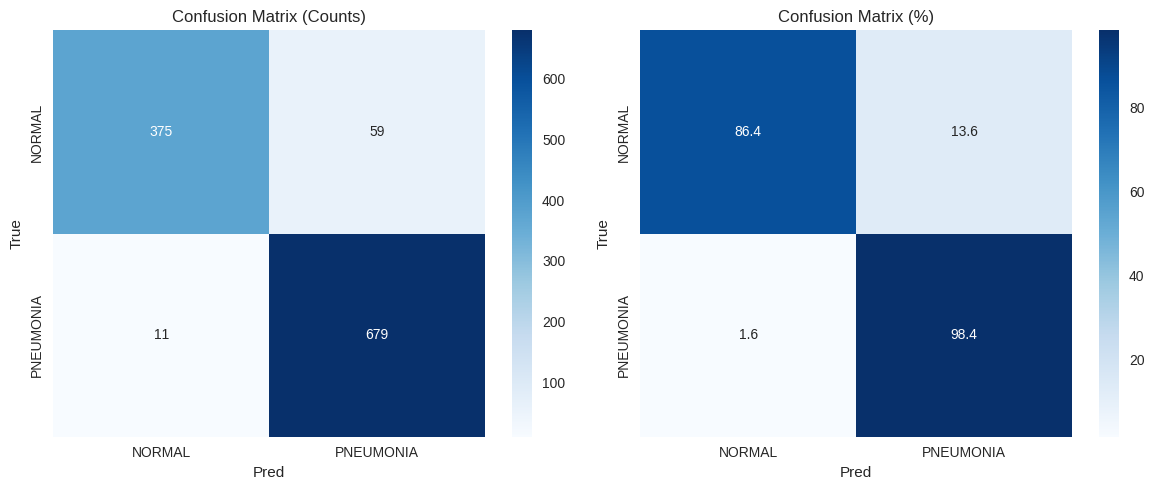

In [ ]:
SAVE_DIR = '/content/results'
TEST_PATH = '/content/drive/MyDrive/chest_xray/test'

import numpy as np, seaborn as sns, matplotlib.pyplot as plt, os
from tensorflow.keras.models import load_model, Model
from keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix

assert os.path.exists(os.path.join(SAVE_DIR, 'vgg16_vde_pneumonia.h5')), 'Missing model .h5'
assert os.path.exists(os.path.join(SAVE_DIR, 'vde_feature_mask.npy')), 'Missing vde_feature_mask.npy'
vde_model = load_model(os.path.join(SAVE_DIR, 'vgg16_vde_pneumonia.h5'))
vde_mask = np.load(os.path.join(SAVE_DIR, 'vde_feature_mask.npy'))

IMAGE_SIZE = (224, 224)
test_datagen = ImageDataGenerator(rescale=1./255)
test_set = test_datagen.flow_from_directory(
    TEST_PATH, target_size=IMAGE_SIZE, batch_size=32, class_mode='categorical', shuffle=False
)
class_names = list(test_set.class_indices.keys())

vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=IMAGE_SIZE + (3,))
feature_extractor = Model(inputs=vgg_base.input, outputs=vgg_base.output)

test_features, test_labels = [], []
for i, (bx, by) in enumerate(test_set):
    if i >= len(test_set): break
    feats = feature_extractor.predict(bx, verbose=0)
    test_features.append(feats); test_labels.append(by)

X = np.concatenate(test_features, axis=0).reshape(len(test_set.filenames), -1)
X_sel = X[:, vde_mask == 1]
y_true = np.argmax(np.concatenate(test_labels, axis=0), axis=1)

y_pred = np.argmax(vde_model.predict(X_sel, verbose=0), axis=1)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Counts)'); plt.ylabel('True'); plt.xlabel('Pred')

plt.subplot(1,2,2)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm*100, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (%)'); plt.ylabel('True'); plt.xlabel('Pred')
plt.tight_layout(); plt.show()

In [29]:
from sklearn.metrics import classification_report
import pandas as pd, os

pd.options.display.float_format = ('{:.' + str(DECIMALS) + 'f}').format

report = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
)

df_metrics = pd.DataFrame(report).transpose().rename(columns={
    'precision': 'Precision',
    'recall': 'Recall',
    'f1-score': 'F1',
    'support': 'Support'
})

df_metrics[['Precision','Recall','F1']] = df_metrics[['Precision','Recall','F1']].round(DECIMALS)
df_metrics['Support'] = df_metrics['Support'].astype(int)

display(df_metrics)

SAVE_DIR = '/content/results'
os.makedirs(SAVE_DIR, exist_ok=True)
df_metrics.to_csv(f'{SAVE_DIR}/precision_recall_f1_support.csv', float_format=f'%.{DECIMALS}f')
print(f'Saved: {SAVE_DIR}/precision_recall_f1_support.csv')

,Precision,Recall,F1,Support
NORMAL,0.971503,0.864055,0.914634,434
PNEUMONIA,0.920054,0.984058,0.950980,690
accuracy,0.937722,0.937722,0.937722,0
macro avg,0.945778,0.924057,0.932807,1124
weighted avg,0.939920,0.937722,0.936946,1124


Saved: /content/results/precision_recall_f1_support.csv


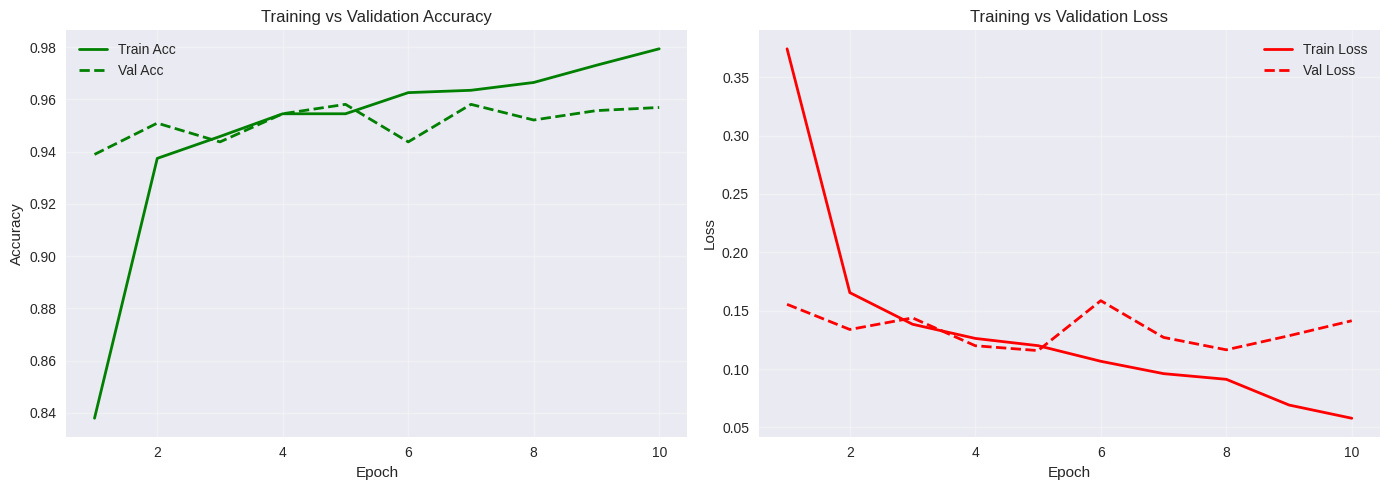

Saved: /content/results/vde_train_val_curves.png


In [30]:
import json, os
import matplotlib.pyplot as plt

SAVE_DIR = '/content/results'
os.makedirs(SAVE_DIR, exist_ok=True)

history_dict = None
try:
    history_dict = vde_history.history  # noqa
except NameError:
    pass

if history_dict is None:
    with open(os.path.join(SAVE_DIR, 'vde_training_history.json'), 'r') as f:
        history_dict = json.load(f)

acc = history_dict.get('accuracy', [])
val_acc = history_dict.get('val_accuracy', [])
loss = history_dict.get('loss', [])
val_loss = history_dict.get('val_loss', [])
epochs = range(1, max(len(acc), len(loss)) + 1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
if acc: plt.plot(epochs, acc, 'g-', label='Train Acc', linewidth=2)
if val_acc: plt.plot(epochs, val_acc, 'g--', label='Val Acc', linewidth=2)
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(True, alpha=0.3); plt.legend()

plt.subplot(1,2,2)
if loss: plt.plot(epochs, loss, 'r-', label='Train Loss', linewidth=2)
if val_loss: plt.plot(epochs, val_loss, 'r--', label='Val Loss', linewidth=2)
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True, alpha=0.3); plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'vde_train_val_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {os.path.join(SAVE_DIR, 'vde_train_val_curves.png')}")

In [ ]:
print("🚀 STEP 8: SAVING ALL DATA")
save_all_global_data()

🚀 STEP 8: SAVING ALL DATA
💾 Saving all data...
✅ All data saved to /content/results


In [ ]:
print("="*70)
print("NOTEBOOK VERIFICATION")
print("="*70)

required_keys = ['vde_model', 'vde_feature_mask', 'feature_extractor', 'vde_history', 'vde_fitness_history']
missing_keys = [key for key in required_keys if GLOBAL_DATA[key] is None]

if missing_keys:
    print(f"❌ Missing data: {missing_keys}")
    print("Please run the previous cells in order.")
else:
    print("✅ All required data is available!")
    print(f"✅ VDE Model: {GLOBAL_DATA['vde_model'] is not None}")
    print(f"✅ Feature Mask: {GLOBAL_DATA['vde_feature_mask'] is not None}")
    print(f"✅ Feature Extractor: {GLOBAL_DATA['feature_extractor'] is not None}")
    print(f"✅ Training History: {GLOBAL_DATA['vde_history'] is not None}")
    print(f"✅ Fitness History: {GLOBAL_DATA['vde_fitness_history'] is not None}")

print("\n🎉 VDE-Enhanced VGG16 Notebook is ready!")
print("📁 All results saved to:", SAVE_DIR)
print("🚀 Ready for Google Colab execution!")


NOTEBOOK VERIFICATION
✅ All required data is available!
✅ VDE Model: True
✅ Feature Mask: True
✅ Feature Extractor: True
✅ Training History: True
✅ Fitness History: True

🎉 VDE-Enhanced VGG16 Notebook is ready!
📁 All results saved to: /content/results
🚀 Ready for Google Colab execution!


Picked indices: 1 8


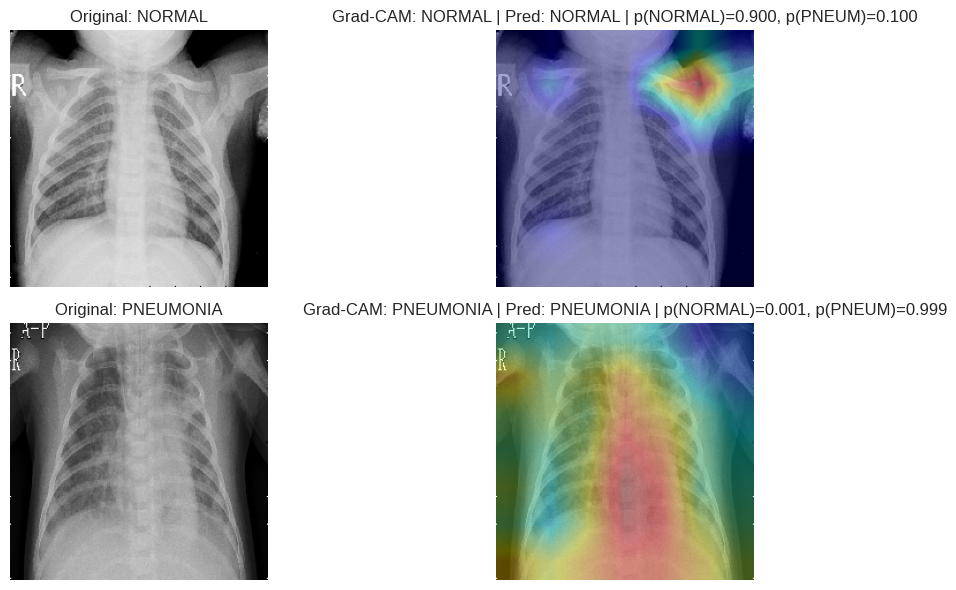

In [43]:
import tensorflow as tf
import cv2

def grad_cam_for_vde(bx, target_class_idx=None):
    with tf.GradientTape() as tape:
        bx = tf.convert_to_tensor(bx)
        tape.watch(bx)
        conv_maps = feature_extractor(bx, training=False)        # (1,H,W,C)
        conv_maps_f = tf.reshape(conv_maps, (1, -1))             # flatten
        selected = tf.boolean_mask(conv_maps_f, tf.constant(vde_mask, dtype=tf.bool), axis=1)# apply VDE mask
        logits = vde_model(selected, training=False)              # (1,num_classes)
        if target_class_idx is None:
            target_class_idx = tf.argmax(logits[0])
        target_score = logits[:, target_class_idx]

    grads = tape.gradient(target_score, conv_maps)               # (1,H,W,C)
    pooled_grads = tf.reduce_mean(grads, axis=(1,2))             # (1,C)
    weights = tf.reshape(pooled_grads, (1,1,1,-1))
    cam = tf.reduce_sum(weights * conv_maps, axis=-1)[0]         # (H,W)
    cam = tf.maximum(cam, 0)
    cam /= (tf.reduce_max(cam) + 1e-8)
    cam = cam.numpy()
    return cam, int(target_class_idx.numpy()), logits.numpy()[0]

def overlay_cam(img_rgb_uint8, cam, alpha=0.35):
    cam_resized = cv2.resize(cam, (img_rgb_uint8.shape[1], img_rgb_uint8.shape[0]))
    heatmap = cv2.applyColorMap((cam_resized*255).astype(np.uint8), cv2.COLORMAP_JET)[:, :, ::-1]
    overlay = (alpha*heatmap + (1-alpha)*img_rgb_uint8).astype(np.uint8)
    return overlay

idx_normal, idx_pneu = None, None
for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
    if idx_normal is None and yt==0 and yp==0: idx_normal = i
    if idx_pneu is None and yt==1 and yp==1: idx_pneu = i
    if idx_normal is not None and idx_pneu is not None: break

print('Picked indices:', idx_normal, idx_pneu)

filepaths = [os.path.join(VAL_PATH, fname) for fname in val_set.filenames]
def load_img_uint8(path, size=IMAGE_SIZE):
    orig = tf.keras.utils.load_img(path, target_size=size)
    arr = tf.keras.utils.img_to_array(orig).astype(np.uint8)
    return arr

samples = [('NORMAL', idx_normal), ('PNEUMONIA', idx_pneu)]
plt.figure(figsize=(12,6))
for j, (label, idx) in enumerate(samples, 1):
    if idx is None:
        print(f"Skipping {label} Grad-CAM as no correctly classified sample was found.")
        continue

    img_uint8 = load_img_uint8(filepaths[idx])
    bx = np.expand_dims(img_uint8/255.0, axis=0)                 # match generator scaling
    cam, target_idx, logits = grad_cam_for_vde(bx, target_class_idx=None)
    overlay = overlay_cam(img_uint8, cam)
    pred_cls = class_names[np.argmax(logits)]
    title = f'{label} | Pred: {pred_cls} | p(NORMAL)={logits[0]:.3f}, p(PNEUM)={logits[1]:.3f}'
    plt.subplot(2,2,2*j-1); plt.imshow(img_uint8); plt.title(f'Original: {label}'); plt.axis('off')
    plt.subplot(2,2,2*j); plt.imshow(overlay); plt.title(f'Grad-CAM: {title}'); plt.axis('off')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/val_gradcam_examples.png', dpi=300); plt.show()

In [42]:
cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix:\n', cm)
for cls_idx, cls_name in enumerate(class_names):
    correct_idxs = [i for i,(yt,yp) in enumerate(zip(y_true,y_pred)) if yt==cls_idx and yp==cls_idx]
    print(f'{cls_name}: correctly predicted {len(correct_idxs)} / {(y_true==cls_idx).sum()}')
    for k in correct_idxs[:3]:
        print('  ✓', val_set.filenames[k])

Confusion Matrix:
 [[7 1]
 [1 7]]
NORMAL: correctly predicted 7 / 8
  ✓ NORMAL/NORMAL2-IM-1430-0001.jpeg
  ✓ NORMAL/NORMAL2-IM-1431-0001.jpeg
  ✓ NORMAL/NORMAL2-IM-1436-0001.jpeg
PNEUMONIA: correctly predicted 7 / 8
  ✓ PNEUMONIA/person1946_bacteria_4874.jpeg
  ✓ PNEUMONIA/person1946_bacteria_4875.jpeg
  ✓ PNEUMONIA/person1947_bacteria_4876.jpeg


In [ ]:
VAL_PATH = '/content/drive/MyDrive/chest_xray/chest_xray/test'
SAVE_DIR = '/content/results'
MODEL_PATH = f'{SAVE_DIR}/vgg16_vde_pneumonia.h5'
MASK_PATH = f'{SAVE_DIR}/vde_feature_mask.npy'

from google.colab import drive; drive.mount('/content/drive')
import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns, tensorflow as tf
from tensorflow.keras.models import load_model, Model
from keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

os.makedirs(SAVE_DIR, exist_ok=True)
IMAGE_SIZE = (224, 224)

# Data generator (no shuffle for consistent indexing)
val_gen = ImageDataGenerator(rescale=1./255)
val_set = val_gen.flow_from_directory(
    VAL_PATH, target_size=IMAGE_SIZE, batch_size=32, class_mode='categorical', shuffle=False
)
class_names = list(val_set.class_indices.keys())

vde_model = load_model(MODEL_PATH)
vde_mask = np.load(MASK_PATH)

# VGG16 feature extractor
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=IMAGE_SIZE + (3,))
feature_extractor = Model(inputs=vgg_base.input, outputs=vgg_base.output)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 624 images belonging to 2 classes.


In [ ]:
val_features, val_labels = [], []
for i, (bx, by) in enumerate(val_set):
    if i >= len(val_set): break
    feats = feature_extractor.predict(bx, verbose=0)
    val_features.append(feats); val_labels.append(by)

F = np.concatenate(val_features, axis=0)
Y = np.concatenate(val_labels, axis=0)
X_flat = F.reshape(F.shape[0], -1)
X_sel = X_flat[:, vde_mask == 1]
y_true = np.argmax(Y, axis=1)

y_pred_proba = vde_model.predict(X_sel, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print('Shapes:', F.shape, X_sel.shape, y_pred_proba.shape)
print('Val accuracy:', (y_pred == y_true).mean())

Shapes: (624, 7, 7, 512) (624, 5650) (624, 2)
Val accuracy: 0.907051282051282


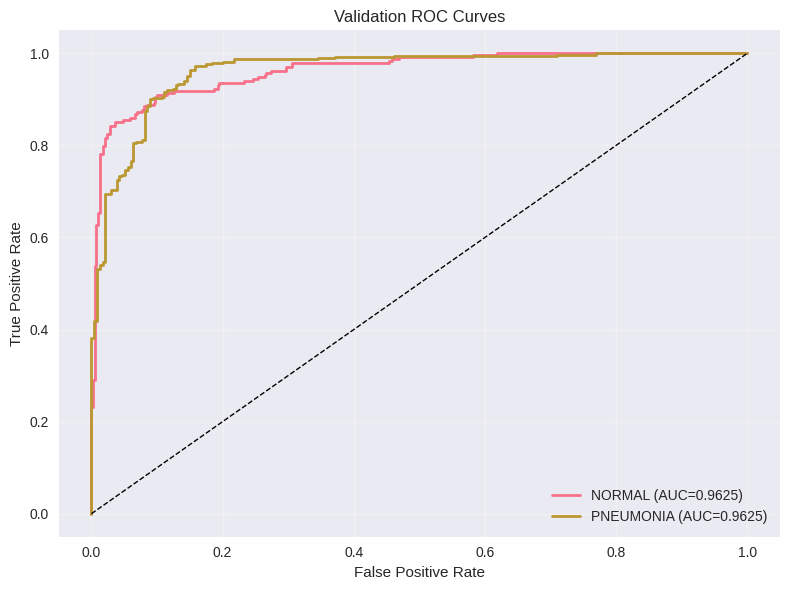

In [47]:
plt.figure(figsize=(8,6))
for i, cls in enumerate(class_names):
    y_true_bin = (y_true == i).astype(int)
    fpr, tpr, _ = roc_curve(y_true_bin, y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{cls} (AUC={roc_auc:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Validation ROC Curves'); plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/val_roc_curves.png', dpi=300); plt.show()

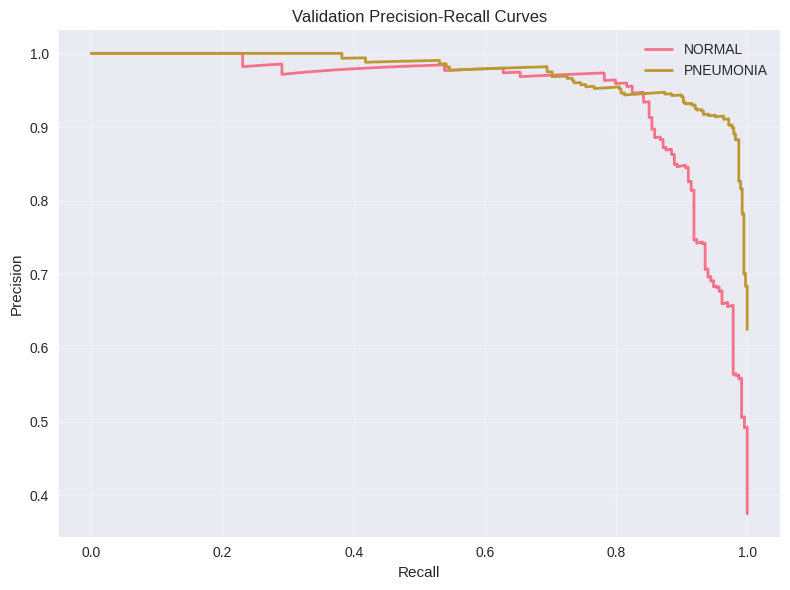

In [48]:
plt.figure(figsize=(8,6))
for i, cls in enumerate(class_names):
    y_true_bin = (y_true == i).astype(int)
    precision, recall, _ = precision_recall_curve(y_true_bin, y_pred_proba[:, i])
    plt.plot(recall, precision, lw=2, label=cls)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Validation Precision-Recall Curves'); plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/val_precision_recall_curves.png', dpi=300); plt.show()

In [49]:
import pandas as pd
DECIMALS = 6
pd.options.display.float_format = ('{:.' + str(DECIMALS) + 'f}').format

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
df_metrics = (pd.DataFrame(report).transpose()
              .rename(columns={'precision':'Precision','recall':'Recall','f1-score':'F1','support':'Support'}))
df_metrics[['Precision','Recall','F1']] = df_metrics[['Precision','Recall','F1']].round(DECIMALS)
df_metrics['Support'] = df_metrics['Support'].astype(int)
display(df_metrics)

df_metrics.to_csv(f'{SAVE_DIR}/val_precision_recall_f1_support.csv', float_format=f'%.{DECIMALS}f')
print(f"Saved: {SAVE_DIR}/val_precision_recall_f1_support.csv")

,Precision,Recall,F1,Support
NORMAL,0.963158,0.782051,0.863208,234
PNEUMONIA,0.882488,0.982051,0.929612,390
accuracy,0.907051,0.907051,0.907051,0
macro avg,0.922823,0.882051,0.896410,624
weighted avg,0.912740,0.907051,0.904710,624


Saved: /content/results/val_precision_recall_f1_support.csv


Picked indices: 0 234


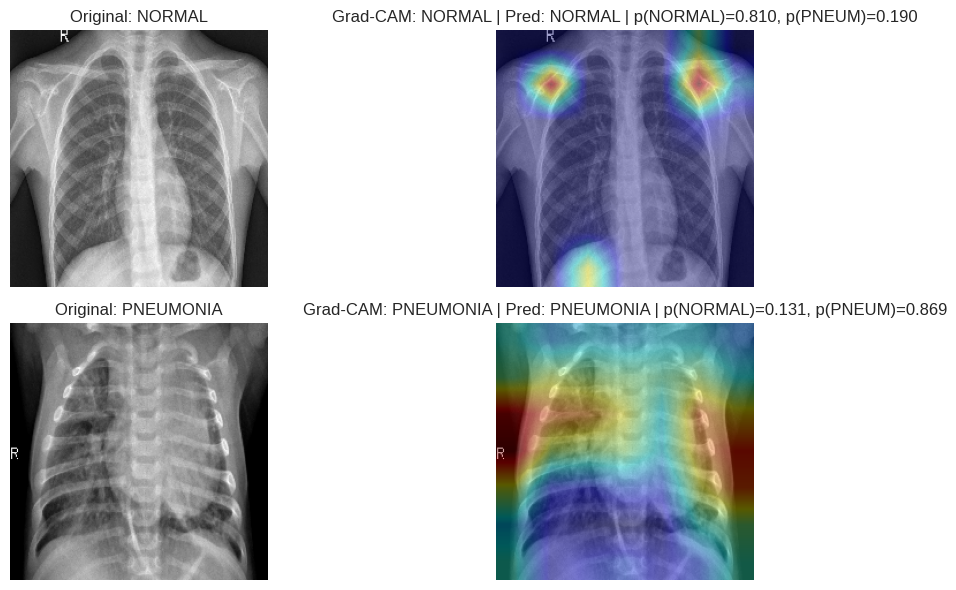

In [51]:
import tensorflow as tf
import cv2

def grad_cam_for_vde(bx, target_class_idx=None):
    with tf.GradientTape() as tape:
        bx = tf.convert_to_tensor(bx)
        tape.watch(bx)
        conv_maps = feature_extractor(bx, training=False)        # (1,H,W,C)
        conv_maps_f = tf.reshape(conv_maps, (1, -1))             # flatten
        selected = tf.boolean_mask(conv_maps_f, tf.constant(vde_mask, dtype=tf.bool), axis=1)# apply VDE mask
        logits = vde_model(selected, training=False)              # (1,num_classes)
        if target_class_idx is None:
            target_class_idx = tf.argmax(logits[0])
        target_score = logits[:, target_class_idx]

    grads = tape.gradient(target_score, conv_maps)               # (1,H,W,C)
    pooled_grads = tf.reduce_mean(grads, axis=(1,2))             # (1,C)
    weights = tf.reshape(pooled_grads, (1,1,1,-1))
    cam = tf.reduce_sum(weights * conv_maps, axis=-1)[0]         # (H,W)
    cam = tf.maximum(cam, 0)
    cam /= (tf.reduce_max(cam) + 1e-8)
    cam = cam.numpy()
    return cam, int(target_class_idx.numpy()), logits.numpy()[0]

def overlay_cam(img_rgb_uint8, cam, alpha=0.35):
    cam_resized = cv2.resize(cam, (img_rgb_uint8.shape[1], img_rgb_uint8.shape[0]))
    heatmap = cv2.applyColorMap((cam_resized*255).astype(np.uint8), cv2.COLORMAP_JET)[:, :, ::-1]
    overlay = (alpha*heatmap + (1-alpha)*img_rgb_uint8).astype(np.uint8)
    return overlay

idx_normal, idx_pneu = None, None
for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
    if idx_normal is None and yt==0 and yp==0: idx_normal = i
    if idx_pneu is None and yt==1 and yp==1: idx_pneu = i
    if idx_normal is not None and idx_pneu is not None: break

print('Picked indices:', idx_normal, idx_pneu)

filepaths = [os.path.join(VAL_PATH, fname) for fname in val_set.filenames]
def load_img_uint8(path, size=IMAGE_SIZE):
    orig = tf.keras.utils.load_img(path, target_size=size)
    arr = tf.keras.utils.img_to_array(orig).astype(np.uint8)
    return arr

samples = [('NORMAL', idx_normal), ('PNEUMONIA', idx_pneu)]
plt.figure(figsize=(12,6))
for j, (label, idx) in enumerate(samples, 1):
    if idx is None:
        print(f"Skipping {label} Grad-CAM as no correctly classified sample was found.")
        continue

    img_uint8 = load_img_uint8(filepaths[idx])
    bx = np.expand_dims(img_uint8/255.0, axis=0)                 # match generator scaling
    cam, target_idx, logits = grad_cam_for_vde(bx, target_class_idx=None)
    overlay = overlay_cam(img_uint8, cam)
    pred_cls = class_names[np.argmax(logits)]
    title = f'{label} | Pred: {pred_cls} | p(NORMAL)={logits[0]:.3f}, p(PNEUM)={logits[1]:.3f}'
    plt.subplot(2,2,2*j-1); plt.imshow(img_uint8); plt.title(f'Original: {label}'); plt.axis('off')
    plt.subplot(2,2,2*j); plt.imshow(overlay); plt.title(f'Grad-CAM: {title}'); plt.axis('off')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/val_gradcam_examples.png', dpi=300); plt.show()

In [52]:
cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix:\n', cm)
for cls_idx, cls_name in enumerate(class_names):
    correct_idxs = [i for i,(yt,yp) in enumerate(zip(y_true,y_pred)) if yt==cls_idx and yp==cls_idx]
    print(f'{cls_name}: correctly predicted {len(correct_idxs)} / {(y_true==cls_idx).sum()}')
    for k in correct_idxs[:3]:
        print('  ✓', val_set.filenames[k])

Confusion Matrix:
 [[183  51]
 [  7 383]]
NORMAL: correctly predicted 183 / 234
  ✓ NORMAL/IM-0001-0001.jpeg
  ✓ NORMAL/IM-0003-0001.jpeg
  ✓ NORMAL/IM-0005-0001.jpeg
PNEUMONIA: correctly predicted 383 / 390
  ✓ PNEUMONIA/person100_bacteria_475.jpeg
  ✓ PNEUMONIA/person100_bacteria_477.jpeg
  ✓ PNEUMONIA/person100_bacteria_478.jpeg
